# Tutorial 1a - Optiland for Beginners

### May 2024

This tutorial describes the basics of Optiland. In particular, the following topics are covered:

- Basic lens entry
- Material definition and selection
- Aperture, field and wavelength selection
- Drawing a lens in 2D and 3D

In [1]:
import numpy as np

from optiland import optic

## Building a Lens - an Overview

 This shows the full code to generate a singlet lens. In the next section, we will go into each part of this code in more detail.

In [2]:
singlet = optic.Optic()

# define surfaces
singlet.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
singlet.surfaces.add(index=1, radius=20, thickness=7, is_stop=True, material="N-SF11")
singlet.surfaces.add(index=2, radius=np.inf, thickness=18)
singlet.surfaces.add(index=3)

# define aperture
singlet.set_aperture(aperture_type="EPD", value=25)

# define fields
singlet.fields.set_type(field_type="angle")
singlet.fields.add(y=0)

# define wavelengths
singlet.wavelengths.add(value=0.5, is_primary=True)

# view in 3D - Note this opens a new window, but we add a photo below to
# show the visualization
singlet.draw3D()

<figure style="text-align: left;">
  <img src="../images/singlet.png" alt="Singlet" style="width: 500px;">
</figure>

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

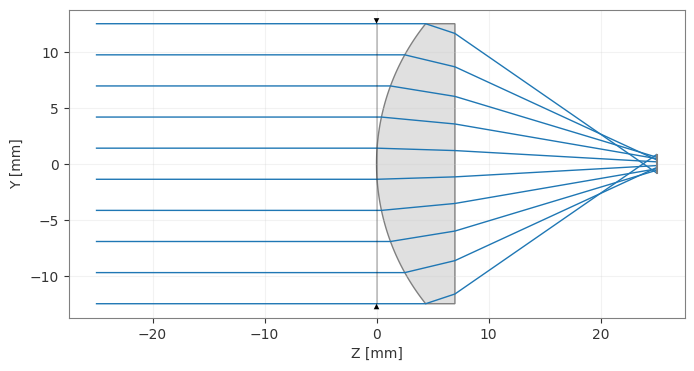

In [3]:
# view in 2D
singlet.draw(num_rays=10)

> **Note:**  
The `draw()` method returns the matplotlib figure and axes.  
When running Optiland in a script, you must explicitly call `plt.show()` or `fig.show()` to display the plot.  

In Jupyter notebooks, figures are displayed automatically.

## Defining a lens, in detail:

### Create the optic:

In Optiland, lenses are instances of the "Optic" class. The process for defining a lens starts with creating an empty "Optic" object as follows:

In [4]:
lens = optic.Optic()

### Add the object surface:

We now want to populate the lens object with surfaces. Let's first add the object surface, which will be at infinity and will have a radius of infinity, i.e. it is a plane. We add the surface by calling the "add_surface" method. We must specify the index as 0 to indicate this is the first surface.

In [5]:
lens.surfaces.add(index=0, radius=np.inf, thickness=np.inf)

### Add a lens:

Let's now add a singlet lens. The lens will be defined as follows:

- Material: N-SF11
- Thickness: 7 mm
- Radius side 1: 20 mm
- Radius side 2: infinity
- Stop surface: 1

Optiland defines lenses one surface at a time, so we define each side of the lens separately. The material always corresponds to the material after interaction with a surface (refraction or reflection). Likewise, the thickness corresponds to the thickness after the surface and it is positive for surfaces to the right. This also implies that we must define the distance from the second surface to the next surface, which we'll define as 18 mm.

Note that we specify the indices of the two surfaces as 1 and 2, after we already specified the object plane with index 0. Also note that Optiland uses millimeters by default.

In [6]:
lens.surfaces.add(index=1, thickness=7, radius=20, is_stop=True, material="N-SF11")
lens.surfaces.add(index=2, radius=np.inf, thickness=18)

### Add image plane:

Lastly, let's add the image plane. By default, the radius is infinity, so we can exclude it. We also can omit thickness, as there are no surfaces beyond the image. We need only to define the index, which is 3.

In [7]:
lens.surfaces.add(index=3)

### Define aperture:

Now, we can define the aperture of the system. Let's choose entrance pupil diameter (EPD) as the aperture type with a value of 25 mm.

The options for aperture type are:

- 'EPD' - entrance pupil diameter
- 'imageFNO' - image-space F-number
- 'objectNA' - object-space numerical aperture
- 'float_by_stop_size' - the aperture size _floats_ with the size of the stop _diameter_, which is defined by the `value` argument.

In [8]:
lens.set_aperture(aperture_type="EPD", value=25)

### Define fields:

Let's add the fields of the lens. We'll keep it simple and add a single field of type "angle" with a value of 0.

The options for field types are:

- 'angle' - the angle of the field in object space
- 'object_height' - the height of the object
- 'paraxial_image_height' - the image height of a paraxial chief ray
- 'real_image_height' - the image height of a real chief ray

In [9]:
lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)

### Define wavelengths:

Lastly, let's define the wavelengths of the system. We define a single wavelength at 0.5 µm. Similar to fields, wavelengths can be assigned a weight to emphasize specific spectral regions.

In [10]:
lens.wavelengths.add(value=0.5, is_primary=True)

### View the lens:

Let's view the lens in 2D. We can do this by calling the `draw` method.

Note that you can also pass a `projection` argument, allowing you to plot in the `"YZ"` plane (default), `"XZ"` plane, or `"XY"` plane.

The 2D visualization is now interactive! You can hover over surfaces, lenses, and ray bundles to get more information. You can also customize the look and feel of the plots using themes. See the gallery for an example of how to use themes.

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

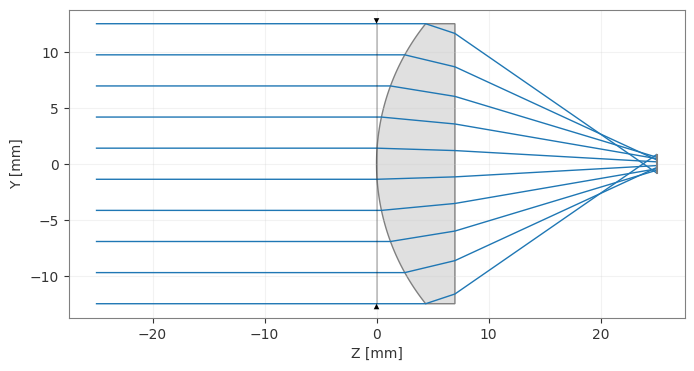

In [11]:
lens.draw(num_rays=10)

Finally, we view the lens in 3D using the "draw3D" function. Note that this opens a new window.

In [12]:
lens.draw3D()